<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.975 · Deep Learning · PAC3</p>
<p style="margin: 0; text-align:right;">2024-2 · Màster universitari en Ciència de dades (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'Informàtica, Multimèdia i Telecomunicació</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PAC 3: Transformers amb Keras


<u>Consideracions generals</u>:

- Aquesta PAC s'ha de realitzar de forma **estrictament individual**. Qualsevol indicatiu de còpia serà penalitzat amb un suspens (D) per a totes les parts implicades i la possible avaluació negativa de l'assignatura de manera íntegra.
- És necessari que l'estudiant indiqui **totes les fonts** que ha utilitzat per a la realització de la PAC. De no ser així, es considerarà que l'estudiant ha comès plagi, sent penalitzat amb un suspens (D) i la possible avaluació negativa de l'assignatura de manera íntegra.

<u>Format de l'entrega</u>:

- Alguns exercicis poden suposar diversos minuts d'execució, per la qual cosa l'entrega s'ha de fer en **format notebook** i en **format html**, on es vegi el codi, els resultats i comentaris de cada exercici. Es pot exportar el notebook a HTML des del menú File $\to$ Download as $\to$ HTML.
- Existeix un tipus de cel·la especial per allotjar text. Aquest tipus de cel·la us serà molt útil per respondre a les diferents preguntes teòriques plantejades al llarg de l'activitat. Per canviar el tipus de cel·la a aquest tipus, en el menú: Cell $\to$ Cell Type $\to$ Markdown.

## Càrrega de llibreries
A continuació es mostren les principals llibreries necessàries per executar aquesta PAC.

In [3]:

!pip install tensorflow[and-cuda]

!pip install tf-keras==2.18.0

!pip install tf-models-official==2.18.0

In [4]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"


In [5]:
import tensorflow as tf
#import keras
from transformers import BertTokenizer, TFBertModel

from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense, Embedding, GlobalAveragePooling1D
#from keras.layers import LSTM, SimpleRNNCell, Flatten, Dropout, MultiHeadAttention, Bidirectional, TimeDistributed, Dense, Embedding
from tensorflow.keras.layers import Permute, dot, add, concatenate
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau


from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow_hub as hub
import tensorflow_text as text
from official.nlp import optimization

import matplotlib.pyplot as plt



2025-05-20 18:07:09.009049: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747764429.032093     439 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747764429.039336     439 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [6]:
print(tf.__version__)
print(hub.__version__)
print(text.__version__)

2.18.0
0.16.1
2.18.1


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Es recomana en aquesta PAC utilitzar tensorflow 2.14. Utilitzar altres versions pot dificultar el treball en la part sobre downstream models a causa de la incompatibilitat de llibreries</strong> </p>
</div>

## Context

En aquesta PAC utilitzarem models de transformers, capes d'atenció, capes bidireccionals i alguns altres algorismes estudiats fins ara per construir i entrenar fent dos exercicis relacionats amb el llenguatge natural. Aquest entorn és on les arquitectures basades en transformers són més potents.


Els objectius de la pràctica són:

* Càrrega, preprocessament, exploració i visualització de les dades.
* Entrenament d'un model base amb els coneixements adquirits fins ara.
* Comprensió de les capes bidireccionals.
* Comprensió i aplicació de les capes d'atenció.
* Comprensió i aplicació de blocs transformers bàsics.
* Comprensió i aplicació de blocs transformers avançats.
* Aplicació sobre domini (downstream models) d'arquitectures preentrenades basades en transformers.
* Adquisició de coneixements i capacitat crítica que permeti continuar millorant els resultats.

## 1 Càrrega de dades (0.5 punts)


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.5 pt]:</strong> IMBD és una base de dades que conté ressenyes de pel·lícules, juntament amb la valoració sobre si el comentari és positiu o negatiu. En aquesta primera part realitza el següent:

* Descarrega la base de dades d'IMBD des de keras i mostra 2 exemples de comentaris positius i 2 exemples de comentaris negatius. Les paraules estan codificades en números, mostra els exemples en text. Tens informació de com fer-ho a: https://www.tensorflow.org/api_docs/python/tf/keras/datasets/imdb/get_word_index
* Reprodueix la taula 1 (només les dades de la fila 3) del paper Long Short-Term Memory with Dynamic Skip Connections (https://arxiv.org/pdf/1811.03873v1). Calcula els valors d'aquesta taula sobre la base de dades de l'IMBD amb què estem treballant. Fes particions de dades o les suposicions que consideris. Si hi hagués alguna diferència amb el paper, indica-la.
</div>

In [7]:
import pandas as pd
start_char = 1
oov_char = 2
index_from = 3
# Retrieve the training sequences.
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.imdb.load_data(seed=113,
    start_char=start_char, oov_char=oov_char, index_from=index_from
)
# Retrieve the word index file mapping words to indices
word_index = tf.keras.datasets.imdb.get_word_index()
# Reverse the word index to obtain a dict mapping indices to words
# And add `index_from` to indices to sync with `x_train`
inverted_word_index = dict(
    (i + index_from, word) for (word, i) in word_index.items()
)
# Update `inverted_word_index` to include `start_char` and `oov_char`
inverted_word_index[start_char] = "[START]"
inverted_word_index[oov_char] = "[OOV]"
# Decode the first sequence in the dataset
def decode(encoded_reveiw):
    return " ".join(inverted_word_index[i] for i in encoded_reveiw)
    
decoded_reviews = [decode(review) for review in x_train_full]
df = pd.DataFrame({
    'review': decoded_reviews,
    'label': y_train_full
})
print(df.head())

                                              review  label
0  [START] this film was just brilliant casting l...      1
1  [START] big hair big boobs bad music and a gia...      0
2  [START] this has to be one of the worst films ...      0
3  [START] the scots excel at storytelling the tr...      1
4  [START] worst mistake of my life br br i picke...      0


In [36]:
print(df[df["label"]==0].head(2))
print(df[df["label"]==1].head(2))

                                              review  label
1  [START] big hair big boobs bad music and a gia...      0
2  [START] this has to be one of the worst films ...      0
                                              review  label
0  [START] this film was just brilliant casting l...      1
3  [START] the scots excel at storytelling the tr...      1


In [24]:
from tabulate import tabulate
print(tabulate([[len(inverted_word_index),len(y_train_full),len(y_test) ,len(df['label'].unique())]], headers=['Vocab', '#Test',"#Test","#class"]))




  Vocab    #Test    #Test    #class
-------  -------  -------  --------
  88586    25000    25000         2


In [10]:
inverted_word_index[52012]

"hold's"

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
Importem les dades i les posem en un df i mostrem 2 positives i 2 negatives. Quan comparem les dades amb les de paper veiem que no coincideixen primer en les paraules si mirem totes les paraules en el dataset segons tf que ja les te separades trobem que arribem a 88 mil que son meny que les 112 mil que posa al paper, això es degut a que el paper va agafar el raw dataset i el va pasar per un tokenitzador, al fer això arribem a aquest valors. Respecte la separacio entre train i test el paper separa train en dos clases per comprovar en concret el 15% per tant tenim 25000 i 25000
</div>


## 2 Model base LSTM (1 punt)


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [1 pt]:</strong>

    
Ara intentarem completar algunes parts de la taula 4 del paper Long Short-Term Memory with Dynamic Skip Connections https://arxiv.org/pdf/1811.03873v1.

Es recomana, en primer lloc, entendre les dificultats que afronta el llenguatge natural. Per això observa la Figura 1 del paper i llegeix la introducció, en particular el penúltim paràgraf.


* En aquesta part, entrena un model simple LSTM tal com apareix a la primera fila de la taula 4. Mostra les gràfiques d'accuracy i loss durant l'entrenament (de la partició d'eval i de train), així com el resultat final sobre test. Repasseu el text corresponent a la secció "Sentiment Analysis on IMDB" per intentar reproduir els resultats. Discuteix les decisions que has hagut de prendre en cas de no tenir tota la informació. Implementa un early stopping i queda't sempre amb el millor model sobre el dataset d'avaluació.
    
</div>

In [39]:
import numpy as np

# Parameters 
vocab_size = 10000
embedding_dim = 400
max_length = 400
lstm_units = 128

# Custom split for train/val
x_train, x_val = x_train_full[:21250], x_train_full[21250:]
y_train, y_val = y_train_full[:21250], y_train_full[21250:]

# Pad sequences
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_length)
x_val = tf.keras.preprocessing.sequence.pad_sequences(x_val, maxlen=max_length)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_length)

# Build model
model_lstm = tf.keras.Sequential()
model_lstm.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim),)
model_lstm.add(tf.keras.layers.LSTM(units=lstm_units, return_sequences=False))
model_lstm.add(tf.keras.layers.Dropout(0.2))
model_lstm.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Summary
model_lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Compile
model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
checkpoint_filepath = '/kaggle/temp/model_lstm.keras'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)
callback = EarlyStopping(monitor='val_loss', patience=3)
history_lstm = model_lstm.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,  
    batch_size=50,
    callbacks=[callback,model_checkpoint_callback]
)

model_lstm.load_weights(checkpoint_filepath)

Epoch 1/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.7244 - loss: 0.5362 - val_accuracy: 0.7720 - val_loss: 0.5916
Epoch 2/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8663 - loss: 0.3237 - val_accuracy: 0.8475 - val_loss: 0.3707
Epoch 3/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8699 - loss: 0.3015 - val_accuracy: 0.8667 - val_loss: 0.3362
Epoch 4/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9412 - loss: 0.1576 - val_accuracy: 0.8725 - val_loss: 0.3453
Epoch 5/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9709 - loss: 0.0897 - val_accuracy: 0.8515 - val_loss: 0.4664
Epoch 6/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9815 - loss: 0.0600 - val_accuracy: 0.8629 - val_loss: 0.4999


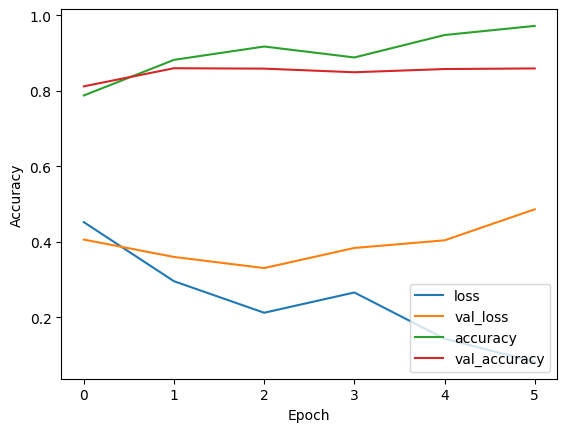

In [40]:
import matplotlib.pyplot as plt
# Funció auxiliar per graficar accuracy i loss
plt.plot(history_lstm.history['loss'], label='loss')
plt.plot(history_lstm.history['val_loss'], label = 'val_loss')
plt.plot(history_lstm.history['accuracy'], label='accuracy')
plt.plot(history_lstm.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

In [43]:
from sklearn.metrics import roc_curve, accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay, classification_report
y_LSTM_pred = model_lstm.predict(x_test)
y_LSTM = [1 if i[0] >= 0.5 else 0 for i in y_LSTM_pred ]
accuracy = accuracy_score(y_test, y_LSTM)
cm = confusion_matrix(y_test, y_LSTM)
sensitivity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
roc_auc = roc_auc_score(y_test,[ i[0] for i in y_LSTM_pred ])
 
print("Logistic Regression - Original Features")
print(f"Accuracy: {accuracy}")
print(f"Sensitivity: {sensitivity}")
print(f"Specificity: {specificity}")
print(f"ROC-AUC: {roc_auc}")
print("Confusion Matrix:")
print(cm)
print(classification_report(y_test, y_LSTM))

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step
Logistic Regression - Original Features
Accuracy: 0.86584
Sensitivity: 0.8336
Specificity: 0.89808
ROC-AUC: 0.9366690816
Confusion Matrix:
[[11226  1274]
 [ 2080 10420]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87     12500
           1       0.89      0.83      0.86     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
Basant-nos en el paper proposat veiem que fan una particio del 15% entre train i validation, el LSTM tindra una capa amb 128 hidden units i una batch size de 50. També veiem que les sequencies les allarguem o les padejem per que totes tiguin 400 paraules, veiem que la nostra accuray es de 0.86 a test quan la del article es de 0.89 no sont molt diferents, crec que aquesta diferencia pot venir per la capa final de desicio o la dels embedings on nosaltres hem agafat x_train on ja tenim vectors on les paraules estan expresades com numeros i hem aprofitat aquesta expresió en canvi el paper utilitzaba "pretrained word2vec embeddings" pot ser aquest canvi explica la.
</div>

 Model | Accuracy |
|-------|----------|
| LSTM  | 0.8624     |

## 3 Model basat en mecanismes d'atenció. (2 punts)



<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [2 pts.]:</strong>
En aquest exercici, hauràs de construir i entrenar una petita arquitectura que combini una capa d'Embedding, mecanismes d'atenció (Multi-Head Attention) i connexions residuals, simulant els principis bàsics dels Transformers. Per això el model constarà:


* Entrada del model.
* Capa d'Embedding: Utilitza una capa Embedding.
* Capa d'Atenció: Incorpora una capa MultiHeadAttention. Aquesta capa ha de rebre com a entrada la seva pròpia sortida, simulant una atenció self-attention.
* Connexió Residual: Afegeix la sortida de la capa d'atenció a la sortida original de la capa d'embedding mitjançant una operació de suma (Add). Posteriorment, aplica una capa de normalització (LayerNormalization).
* Capa de Flatten i Regularització.
* Finalment afegeix una darrera capa classificadora d'una neurona i activació sigmoide

Amb aquesta arquitectura hauràs de:
* Mostrar el resum del model i el diagrama de blocs.
* Entrenar el model i obtenir els resultats sobre test. Mostra les corbes d'entrenament. Quan entrenis el model, també implementa un early stopping i queda't amb el model que et doni millors resultats en validació.
* Comenta i discuteix què has realitzat. Compara els teus resultats amb els obtinguts anteriorment. Amplia la taula de resultats demanada a l'exercici anterior. Pren les decisions sobre els paràmetres que consideris.

In [17]:
# Suport layer MHA + Add + Normalization
class CrossAttention(tf.keras.layers.Layer):
  def __init__(self, units, num_heads, **kwargs):
    super().__init__()
    self.mha = tf.keras.layers.MultiHeadAttention(key_dim=units, num_heads=num_heads, **kwargs)
    self.layernorm = tf.keras.layers.LayerNormalization()
    self.add = tf.keras.layers.Add()

  def call(self, x):

    attn_output  = self.mha(
        query=x,
        value=x)   

    x = self.add([x, attn_output])
    x = self.layernorm(x)

    return x
# Parameters 
vocab_size = 10000
embedding_dim = 400
max_length = 400
self_att_units = 400
num_heads = 4
# Custom split for train/val
x_train, x_val = x_train_full[:21250], x_train_full[21250:]
y_train, y_val = y_train_full[:21250], y_train_full[21250:]

# Pad sequences
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_length)
x_val = tf.keras.preprocessing.sequence.pad_sequences(x_val, maxlen=max_length)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_length)

# Build model
model_atent = tf.keras.Sequential()
model_atent.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),)
model_atent.add(CrossAttention(units=self_att_units, num_heads=num_heads))
model_atent.add(tf.keras.layers.Flatten())
model_atent.add(tf.keras.layers.Dropout(0.3))
model_atent.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model_atent.compile(optimizer='adam', loss='mean_squared_error')

# Summary
model_atent.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 400, 400)          4000000   
                                                                 
 cross_attention_1 (CrossAt  (None, 400, 400)          2566000   
 tention)                                                        
                                                                 
 flatten_1 (Flatten)         (None, 160000)            0         
                                                                 
 dropout_2 (Dropout)         (None, 160000)            0         
                                                                 
 dense_2 (Dense)             (None, 1)                 160001    
                                                                 
Total params: 6726001 (25.66 MB)
Trainable params: 6726001 (25.66 MB)
Non-trainable params: 0 (0.00 Byte)
______________

In [18]:
# Compile
model_atent.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
checkpoint_filepath = '/kaggle/temp/model_att'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)
# Train
callback = EarlyStopping(monitor='val_loss', patience=3)
history_atent = model_atent.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,  
    batch_size=50,
    callbacks=[callback, model_checkpoint_callback]
)
model_atent.load_weights(checkpoint_filepath)

Epoch 1/50
425/425 [==============================] - 118s 273ms/step - loss: 0.9997 - accuracy: 0.7184 - val_loss: 0.6298 - val_accuracy: 0.8344
Epoch 2/50
425/425 [==============================] - 107s 250ms/step - loss: 0.1663 - accuracy: 0.9513 - val_loss: 0.7619 - val_accuracy: 0.8253
Epoch 3/50
425/425 [==============================] - 105s 248ms/step - loss: 0.0508 - accuracy: 0.9830 - val_loss: 0.7883 - val_accuracy: 0.8555
Epoch 4/50
425/425 [==============================] - 104s 244ms/step - loss: 0.0346 - accuracy: 0.9893 - val_loss: 1.0140 - val_accuracy: 0.8576


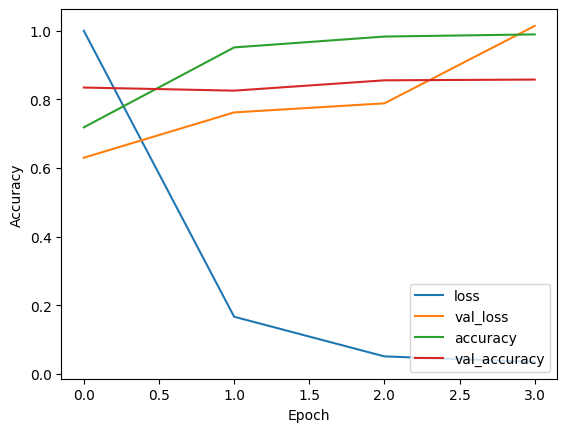

In [19]:
import matplotlib.pyplot as plt
# Funció auxiliar per graficar accuracy i loss
plt.plot(history_atent.history['loss'], label='loss')
plt.plot(history_atent.history['val_loss'], label = 'val_loss')
plt.plot(history_atent.history['accuracy'], label='accuracy')
plt.plot(history_atent.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

In [20]:
from sklearn.metrics import roc_curve, accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay, classification_report
y_atent_pred = model_atent.predict(x_test)
y_atent = [1 if i[0] >= 0.5 else 0 for i in y_atent_pred ]
accuracy = accuracy_score(y_test, y_atent)
cm = confusion_matrix(y_test, y_atent)
sensitivity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
roc_auc = roc_auc_score(y_test,[ i[0] for i in y_atent_pred ])
 
print("Logistic Regression - Original Features")
print(f"Accuracy: {accuracy}")
print(f"Sensitivity: {sensitivity}")
print(f"Specificity: {specificity}")
print(f"ROC-AUC: {roc_auc}")
print("Confusion Matrix:")
print(cm)
print(classification_report(y_test, y_atent))

782/782 [==============================] - 36s 46ms/step
Logistic Regression - Original Features
Accuracy: 0.85056
Sensitivity: 0.876
Specificity: 0.82512
ROC-AUC: 0.929236784
Confusion Matrix:
[[10314  2186]
 [ 1550 10950]]
              precision    recall  f1-score   support

           0       0.87      0.83      0.85     12500
           1       0.83      0.88      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
    He creat una funció la qual té la capa de altencio una de suma i la de regularitzacio on els imputs són els de la entrada de dades i el output de la capa de autoatenció. Despres he aplanat les variables i he fet un drop per intentar evitar el sobre ajust per acabar amb una capa d'activacio sigmoide, com podem veure el resultat del model es una accuracy de 0.85 que es una mica pitjor que abans encara que segueix sent un model funcional
</div>


 Model | Accuracy |
|-------|----------|
| LSTM  | 0.8624     |
| ATT_simple  | 0.85056     |


## 4 Model basat en mecanismes d'atenció millorat. (0.5 punts)



<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.5 pts.]:</strong>
Fes alguna modificació sobre l'arquitectura anterior i reentrena el model. Algunes idees poden ser: afegir diversos caps d'atenció, modificar els residus, incloure-hi alguna capa recurrent, etc.

In [21]:
class CrossAttention(tf.keras.layers.Layer):
  def __init__(self, units, num_heads, dropout=0.1, **kwargs):
    super().__init__()
    self.mha = tf.keras.layers.MultiHeadAttention(key_dim=units, num_heads=num_heads, **kwargs)
    self.dropout = tf.keras.layers.Dropout(dropout)
    self.layernorm = tf.keras.layers.LayerNormalization()
    self.add = tf.keras.layers.Add()

  def call(self, x):

    attn_output  = self.mha(
        query=x,
        value=x)   
    attn_output = self.dropout(attn_output)
    x = self.add([x, attn_output])
    x = self.layernorm(x)

    return x
model_atent2 = tf.keras.Sequential()
model_atent2.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),)
model_atent2.add(CrossAttention(units=self_att_units, num_heads=num_heads))
model_atent2.add(CrossAttention(units=self_att_units, num_heads=num_heads))
model_atent2.add(tf.keras.layers.LSTM(64, return_sequences=False))
model_atent2.add(tf.keras.layers.Dropout(0.3))
model_atent2.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model_atent2.compile(optimizer='adam', loss='mean_squared_error')


# Summary
model_atent2.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 400, 400)          4000000   
                                                                 
 cross_attention_2 (CrossAt  (None, 400, 400)          2566000   
 tention)                                                        
                                                                 
 cross_attention_3 (CrossAt  (None, 400, 400)          2566000   
 tention)                                                        
                                                                 
 lstm_1 (LSTM)               (None, 64)                119040    
                                                                 
 dropout_5 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                

In [22]:
# Compile
model_atent2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
checkpoint_filepath = '/kaggle/temp/model_att2'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)
# Train
callback = EarlyStopping(monitor='val_loss', patience=5)
history_atent = model_atent2.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,  
    batch_size=50,
    callbacks=[callback, model_checkpoint_callback]
)
model_atent2.load_weights(checkpoint_filepath)

Epoch 1/50
425/425 [==============================] - 221s 507ms/step - loss: 0.6959 - accuracy: 0.5060 - val_loss: 0.6791 - val_accuracy: 0.4949
Epoch 2/50
425/425 [==============================] - 212s 500ms/step - loss: 0.5969 - accuracy: 0.6637 - val_loss: 0.5024 - val_accuracy: 0.7672
Epoch 3/50
425/425 [==============================] - 209s 492ms/step - loss: 0.4067 - accuracy: 0.8223 - val_loss: 0.3820 - val_accuracy: 0.8360
Epoch 4/50
425/425 [==============================] - 208s 489ms/step - loss: 0.2905 - accuracy: 0.8820 - val_loss: 0.3213 - val_accuracy: 0.8656
Epoch 5/50
425/425 [==============================] - 205s 483ms/step - loss: 0.2227 - accuracy: 0.9168 - val_loss: 0.3252 - val_accuracy: 0.8613
Epoch 6/50
425/425 [==============================] - 214s 503ms/step - loss: 0.1998 - accuracy: 0.9275 - val_loss: 0.4203 - val_accuracy: 0.8213
Epoch 7/50
425/425 [==============================] - 215s 506ms/step - loss: 0.2501 - accuracy: 0.9044 - val_loss: 0.3877 -

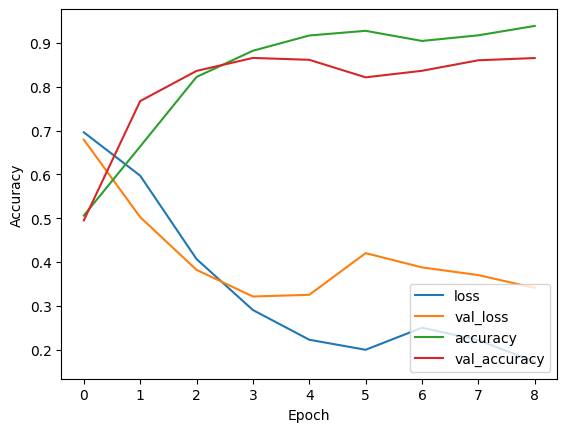

In [23]:
import matplotlib.pyplot as plt
# Funció auxiliar per graficar accuracy i loss
plt.plot(history_atent.history['loss'], label='loss')
plt.plot(history_atent.history['val_loss'], label = 'val_loss')
plt.plot(history_atent.history['accuracy'], label='accuracy')
plt.plot(history_atent.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

In [24]:
from sklearn.metrics import roc_curve, accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay, classification_report
y_atent_pred = model_atent2.predict(x_test)
y_atent = [1 if i[0] >= 0.5 else 0 for i in y_atent_pred ]
accuracy = accuracy_score(y_test, y_atent)
cm = confusion_matrix(y_test, y_atent)
sensitivity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
roc_auc = roc_auc_score(y_test,[ i[0] for i in y_atent_pred ])
 
print("Logistic Regression - Original Features")
print(f"Accuracy: {accuracy}")
print(f"Sensitivity: {sensitivity}")
print(f"Specificity: {specificity}")
print(f"ROC-AUC: {roc_auc}")
print("Confusion Matrix:")
print(cm)
print(classification_report(y_test, y_atent))

782/782 [==============================] - 76s 97ms/step
Logistic Regression - Original Features
Accuracy: 0.86644
Sensitivity: 0.90104
Specificity: 0.83184
ROC-AUC: 0.9391833824
Confusion Matrix:
[[10398  2102]
 [ 1237 11263]]
              precision    recall  f1-score   support

           0       0.89      0.83      0.86     12500
           1       0.84      0.90      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p> 
    He afegit una altre capa recurent seguida d'una lstm i veiem com el model ha millorat en un 1,6%
</div>

 Model | Accuracy |
|-------|----------|
| LSTM  | 0.8624     |
| ATT_simple  | 0.85056     |
| ATT_multiple | 0.86644   |



## 5 Downstream model. (3 punts)
Un model downstream (o tasca downstream) és un model o tasca que utilitza un model preentrenat en una fase anterior, sovint coneguda com a fase de preentrenament, per resoldre una tasca específica. Aquest model posteriorment es fa servir mitjançant un entrenament específic per resoldre una tasca diferent. Si la tasca té característiques similars i l'arquitectura de la xarxa és prou complexa com per captar els fonaments compartits, és una estratègia que porta molts avantatges.

Un dels grans avantatges dels Transformers és la seva escalabilitat. Per entendre això es recomana ampliar els coneixements amb alguns recursos divulgatius com els següents:
* https://www.youtube.com/watch?v=EFkbT-1VGTQ
* https://www.fabricatedknowledge.com/p/ai-foundations-part-1-transformers
* https://www.baeldung.com/cs/rnns-transformers-nlp

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [2 pt]:</strong>

En aquest exercici prendrem les dades que hem utilitzat fins ara i farem un downstream model del model BERT. Aquesta part està mostrada al següent tutorial: https://www.tensorflow.org/text/tutorials/classify_text_with_bert

Hauràs d'adaptar-la per treballar amb les dades que hem carregat anteriorment. Tria la versió del model que consideris i pren les decisions adequades justificant-les posteriorment. La dificultat principal en aquest exercici és adaptar el codi del tutorial a les dades i particions que has carregat durant l'exercici. Per això:
* Entrena un model amb l'arquitectura BERT més petita mostrada al tutorial anterior. Trieu adequadament el nombre d'èpoques i controleu l'entrenament amb un early stopping
* Mostra el resum del model amb el nombre de paràmetres
* Mostra les gràfiques d'entrenament i validació.
* Finalment completa la taula de resultats i mostra-la

</div>

In [8]:
bert_model_name = 'small_bert/bert_en_uncased_L-4_H-512_A-8' 
map_name_to_handle = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_L-12_H-768_A-12/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_L-12_H-768_A-12/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-768_A-12/1',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_base/2',
    'electra_small':
        'https://tfhub.dev/google/electra_small/2',
    'electra_base':
        'https://tfhub.dev/google/electra_base/2',
    'experts_pubmed':
        'https://tfhub.dev/google/experts/bert/pubmed/2',
    'experts_wiki_books':
        'https://tfhub.dev/google/experts/bert/wiki_books/2',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/talkheads_ggelu_bert_en_base/1',
}

map_model_to_preprocess = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_preprocess/3',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_preprocess/3',
    'electra_small':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'electra_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_pubmed':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_wiki_books':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
}

tfhub_handle_encoder = map_name_to_handle[bert_model_name]
tfhub_handle_preprocess = map_model_to_preprocess[bert_model_name]

print(f'BERT model selected           : {tfhub_handle_encoder}')
print(f'Preprocess model auto-selected: {tfhub_handle_preprocess}')


BERT model selected           : https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3


In [9]:
bert_preprocess_model = hub.KerasLayer(tfhub_handle_preprocess)
bert_model = hub.KerasLayer(tfhub_handle_encoder)

I0000 00:00:1747764442.608254     439 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747764442.608877     439 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.imdb.load_data(seed=113,
    start_char=start_char, oov_char=oov_char, index_from=index_from
)

In [11]:
x_train, x_val = x_train_full[:21250], x_train_full[21250:]
y_train, y_val = y_train_full[:21250], y_train_full[21250:]
x_train_bert = [decode(review) for review in x_train]
x_val_bert = [decode(review) for review in x_val]
x_test_bert = [decode(review) for review in x_test]
train_ds = tf.data.Dataset.from_tensor_slices((x_train_bert, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((x_val_bert, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((x_test_bert, y_test))


BATCH_SIZE = 32

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [12]:
def build_classifier_model():
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)
    net = outputs['pooled_output']
    net = tf.keras.layers.Dropout(0.1)(net)
    net = tf.keras.layers.Dense(1, activation=None, name='classifier')(net)
    return tf.keras.Model(text_input, net)


In [13]:
classifier_model = build_classifier_model()
tf.keras.utils.plot_model(classifier_model)
classifier_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_mask': (None, 128)   0         ['text[0][0]']                
                             , 'input_type_ids': (None,                                           
                              128),                                                               
                              'input_word_ids': (None,                                            
                             128)}                                                                
                                                                                              

In [14]:

loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
metrics = tf.metrics.BinaryAccuracy()
epochs = 10
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1*num_train_steps)

init_lr = 3e-5
optimizer = optimization.create_optimizer(init_lr=init_lr,
                                          num_train_steps=num_train_steps,
                                          num_warmup_steps=num_warmup_steps,
                                          optimizer_type='adamw')
checkpoint_filepath = '/kaggle/temp/model_att2'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)
# Train
callback = EarlyStopping(monitor='val_loss', patience=5)

classifier_model.compile(optimizer=optimizer,
                         loss=loss,
                         metrics=metrics)
history = classifier_model.fit(train_ds,
                            validation_data=val_ds,
                               epochs=epochs,
                              callbacks=[callback, model_checkpoint_callback])


Epoch 1/10
665/665 [==============================] - 155s 217ms/step - loss: 0.4906 - binary_accuracy: 0.7342 - val_loss: 0.3837 - val_binary_accuracy: 0.8320
Epoch 2/10
665/665 [==============================] - 144s 216ms/step - loss: 0.3383 - binary_accuracy: 0.8488 - val_loss: 0.3839 - val_binary_accuracy: 0.8533
Epoch 3/10
665/665 [==============================] - 144s 216ms/step - loss: 0.2494 - binary_accuracy: 0.8952 - val_loss: 0.4272 - val_binary_accuracy: 0.8632
Epoch 4/10
665/665 [==============================] - 144s 216ms/step - loss: 0.1832 - binary_accuracy: 0.9292 - val_loss: 0.5371 - val_binary_accuracy: 0.8584
Epoch 5/10
665/665 [==============================] - 144s 217ms/step - loss: 0.1382 - binary_accuracy: 0.9508 - val_loss: 0.5831 - val_binary_accuracy: 0.8605
Epoch 6/10
665/665 [==============================] - 144s 216ms/step - loss: 0.1037 - binary_accuracy: 0.9664 - val_loss: 0.6816 - val_binary_accuracy: 0.8579


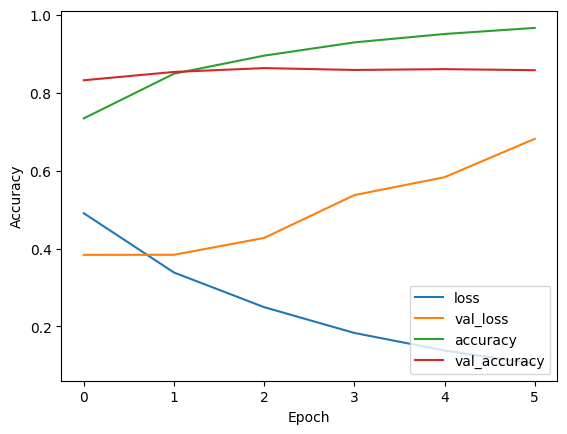

In [15]:
import matplotlib.pyplot as plt
# Funció auxiliar per graficar accuracy i loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.plot(history.history['binary_accuracy'], label='accuracy')
plt.plot(history.history['val_binary_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

In [16]:
from sklearn.metrics import roc_curve, accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay, classification_report
y_atent_pred = classifier_model.predict(test_ds)

782/782 [==============================] - 59s 75ms/step


In [17]:

y_atent = [1 if i[0] >= 0.5 else 0 for i in y_atent_pred ]
accuracy = accuracy_score(y_test, y_atent)
cm = confusion_matrix(y_test, y_atent)
sensitivity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
roc_auc = roc_auc_score(y_test,[ i[0] for i in y_atent_pred ])
 
print("Logistic Regression - Original Features")
print(f"Accuracy: {accuracy}")
print(f"Sensitivity: {sensitivity}")
print(f"Specificity: {specificity}")
print(f"ROC-AUC: {roc_auc}")
print("Confusion Matrix:")
print(cm)
print(classification_report(y_test, y_atent))

Logistic Regression - Original Features
Accuracy: 0.85628
Sensitivity: 0.8284
Specificity: 0.88416
ROC-AUC: 0.9346748255999999
Confusion Matrix:
[[11052  1448]
 [ 2145 10355]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86     12500
           1       0.88      0.83      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
    Hem preprocesat les dades perque tinguin la forma que demana bert per funcionar, una vegada fet això introduim per la pipeline proposada en l'exemple i veiem que tenim una accuracy més alta
</div>

 Model | Accuracy |
|-------|----------|
| LSTM  | 0.8624     |
| ATT_simple  | 0.85056     |
| ATT_multiple | 0.86644   |
| Bert_basic | 0.85628   |


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [1 pt]:</strong>

Repeteix l'exercici anterior però ara fent servir un model BERT més gran. Heu d'utilitzar un model que sigui capaç d'obtenir millors resultats que en tots els casos anteriors. Finetunejar un model gran pot requerir diverses hores.
* Afegeix a la taula de resultats, el resultat obtingut amb aquest model.
* Igual que abans representa les gràfiques d'accuracy i loss.
* Comenta els resultats i discuteix els temps d'entrenament emprats

</div>

In [21]:
bert_model_name = 'bert_en_uncased_L-12_H-768_A-12' 
map_name_to_handle = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_L-12_H-768_A-12/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_L-12_H-768_A-12/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-768_A-12/1',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_base/2',
    'electra_small':
        'https://tfhub.dev/google/electra_small/2',
    'electra_base':
        'https://tfhub.dev/google/electra_base/2',
    'experts_pubmed':
        'https://tfhub.dev/google/experts/bert/pubmed/2',
    'experts_wiki_books':
        'https://tfhub.dev/google/experts/bert/wiki_books/2',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/talkheads_ggelu_bert_en_base/1',
}

map_model_to_preprocess = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_preprocess/3',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_preprocess/3',
    'electra_small':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'electra_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_pubmed':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_wiki_books':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
}

tfhub_handle_encoder = map_name_to_handle[bert_model_name]
tfhub_handle_preprocess = map_model_to_preprocess[bert_model_name]

print(f'BERT model selected           : {tfhub_handle_encoder}')
print(f'Preprocess model auto-selected: {tfhub_handle_preprocess}')


BERT model selected           : https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3
Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3


In [12]:
def build_classifier_model2():
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)
    net = outputs['pooled_output']
    net = tf.keras.layers.Dropout(0.3)(net)
#    net = tf.keras.layers.Dense(128, activation='relu')(net)
#    net = tf.keras.layers.Dropout(0.5)(net)
    net = tf.keras.layers.Dense(1, activation='sigmoid', name='classifier')(net)
    return tf.keras.Model(text_input, net)


In [13]:
classifier_model_big = build_classifier_model2()
classifier_model_big.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_mask': (None, 128)   0         ['text[0][0]']                
                             , 'input_type_ids': (None,                                           
                              128),                                                               
                              'input_word_ids': (None,                                            
                             128)}                                                                
                                                                                              

In [14]:
(x_train_full, y_train_full), (x_test, y_test)

# Convert to strings
train_texts = [decode(review) for review in x_train_full]
test_texts = [decode(review) for review in x_test]

In [15]:
import numpy as np
classifier_model_big = build_classifier_model2()
loss = tf.keras.losses.BinaryCrossentropy(from_logits=False)
metrics = tf.metrics.BinaryAccuracy()
epochs = 5
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1*num_train_steps)

init_lr = 3e-5
optimizer = optimization.create_optimizer(init_lr=init_lr,
                                          num_train_steps=num_train_steps,
                                          num_warmup_steps=num_warmup_steps,
                                          optimizer_type='adamw')
checkpoint_filepath = '/kaggle/temp/model_att2'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)
# Train
callback = EarlyStopping(monitor='val_loss', patience=5)

classifier_model_big.compile(optimizer=optimizer,
                         loss=loss,
                         metrics=metrics)
history = classifier_model_big.fit(x=np.array(train_texts), y=np.array(y_train_full),
                            validation_split=0.15,
                               epochs=epochs, batch_size=32,
                              callbacks=[callback, model_checkpoint_callback])


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/tf_keras/src/backend.py:5820: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


665/665 [==============================] - 686s 988ms/step - loss: 0.4150 - binary_accuracy: 0.7967 - val_loss: 0.2788 - val_binary_accuracy: 0.8805
Epoch 2/5
665/665 [==============================] - 658s 989ms/step - loss: 0.2297 - binary_accuracy: 0.9113 - val_loss: 0.2801 - val_binary_accuracy: 0.8872
Epoch 3/5
665/665 [==============================] - 658s 990ms/step - loss: 0.1181 - binary_accuracy: 0.9610 - val_loss: 0.4180 - val_binary_accuracy: 0.8869
Epoch 4/5
665/665 [==============================] - 658s 989ms/step - loss: 0.0607 - binary_accuracy: 0.9836 - val_loss: 0.5627 - val_binary_accuracy: 0.8811
Epoch 5/5
665/665 [==============================] - 658s 989ms/step - loss: 0.0287 - binary_accuracy: 0.9927 - val_loss: 0.6146 - val_binary_accuracy: 0.8851


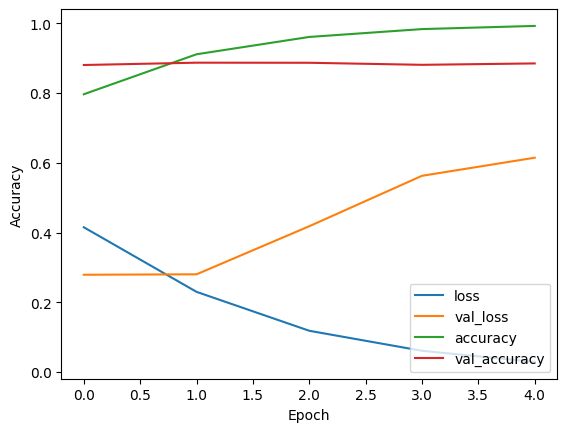

In [16]:
import matplotlib.pyplot as plt
# Funció auxiliar per graficar accuracy i loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.plot(history.history['binary_accuracy'], label='accuracy')
plt.plot(history.history['val_binary_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

In [17]:
from sklearn.metrics import roc_curve, accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay, classification_report
y_atent_pred = classifier_model_big.predict(np.array(test_texts))
y_atent = [1 if i[0] >= 0.5 else 0 for i in y_atent_pred ]
accuracy = accuracy_score(y_test, y_atent)
cm = confusion_matrix(y_test, y_atent)
sensitivity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
roc_auc = roc_auc_score(y_test,[ i[0] for i in y_atent_pred ])
 
print("Logistic Regression - Original Features")
print(f"Accuracy: {accuracy}")
print(f"Sensitivity: {sensitivity}")
print(f"Specificity: {specificity}")
print(f"ROC-AUC: {roc_auc}")
print("Confusion Matrix:")
print(cm)
print(classification_report(y_test, y_atent))

782/782 [==============================] - 246s 314ms/step
Logistic Regression - Original Features
Accuracy: 0.89096
Sensitivity: 0.89592
Specificity: 0.886
ROC-AUC: 0.9540262335999998
Confusion Matrix:
[[11075  1425]
 [ 1301 11199]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     12500
           1       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
    Veiem que amb les mateixes layer nomes canviant la versio de bert utilitzada pujem la accuracy casi un 4% i es la millor obtinguda fins ara
</div>

 Model | Accuracy |
|-------|----------|
| LSTM  | 0.8624     |
| ATT_simple  | 0.85056     |
| ATT_multiple | 0.86644   |
| Bert_basic | 0.85628   |
| Bert_biger | 0.89096   |

## 6 Optimitzant els entrenaments. (2 punts)
Hauràs observat que un dels desavantatges de les grans arquitectures transformers de xarxes neuronals és que requereixen una gran potència de còmput per entrenar-se correctament. Això no és només un problema de temps, sinó de diners.
El maquinari i l'electricitat suposen el cost operatiu principal d'aquestes arquitectures, per la qual cosa optimitzar-les és primordial i suposa un avantatge competitiu (vegeu el cas de DeepSeek).

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.5 pt]:</strong>

Repeteix l'exercici anterior però ara només prova les últimes capes. És a dir, en aquest cas el bloc BERT es queda congelat. Podeu provar d'afegir alguna capa entre el bloc BERT i la sortida.
* Afegeix a la taula de resultats, el resultat obtingut amb aquest model
* Comenta els resultats i discuteix els temps d'entrenament emprats. És una estratègia útil? Quines altres alternatives similars hi ha?

</div>

In [18]:
bert_layer = classifier_model.get_layer('BERT_encoder')
bert_layer.trainable = False
def build_classifier_model_freeze():
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    encoder = bert_layer
    outputs = encoder(encoder_inputs)
    net = outputs['pooled_output']
    net = tf.keras.layers.Dropout(0.3)(net)
    net = tf.keras.layers.Dense(128, activation='relu')(net)
    net = tf.keras.layers.Dropout(0.5)(net)
    net = tf.keras.layers.Dense(1, activation='sigmoid', name='classifier')(net)
    return tf.keras.Model(text_input, net)


In [19]:
classifier_model_freeze = build_classifier_model_freeze()
classifier_model_freeze.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_mask': (None, 128)   0         ['text[0][0]']                
                             , 'input_type_ids': (None,                                           
                              128),                                                               
                              'input_word_ids': (None,                                            
                             128)}                                                                
                                                                                            

In [20]:

loss = tf.keras.losses.BinaryCrossentropy(from_logits=False)
metrics = tf.metrics.BinaryAccuracy()
epochs = 10
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1*num_train_steps)

init_lr = 3e-5
optimizer = optimization.create_optimizer(init_lr=init_lr,
                                          num_train_steps=num_train_steps,
                                          num_warmup_steps=num_warmup_steps,
                                          optimizer_type='adamw')
checkpoint_filepath = '/kaggle/temp/model_att2'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)
# Train
callback = EarlyStopping(monitor='val_loss', patience=5)

classifier_model_freeze.compile(optimizer=optimizer,
                         loss=loss,
                         metrics=metrics)
history = classifier_model_freeze.fit(train_ds,
                            validation_data=val_ds,
                               epochs=epochs,
                              callbacks=[callback, model_checkpoint_callback])


Epoch 1/10
665/665 [==============================] - 67s 92ms/step - loss: 0.2844 - binary_accuracy: 0.8606 - val_loss: 0.5112 - val_binary_accuracy: 0.8595
Epoch 2/10
665/665 [==============================] - 60s 91ms/step - loss: 0.0409 - binary_accuracy: 0.9885 - val_loss: 0.5947 - val_binary_accuracy: 0.8600
Epoch 3/10
665/665 [==============================] - 61s 91ms/step - loss: 0.0381 - binary_accuracy: 0.9896 - val_loss: 0.6208 - val_binary_accuracy: 0.8597
Epoch 4/10
665/665 [==============================] - 61s 91ms/step - loss: 0.0391 - binary_accuracy: 0.9889 - val_loss: 0.6201 - val_binary_accuracy: 0.8597
Epoch 5/10
665/665 [==============================] - 60s 91ms/step - loss: 0.0370 - binary_accuracy: 0.9896 - val_loss: 0.6222 - val_binary_accuracy: 0.8597
Epoch 6/10
665/665 [==============================] - 60s 91ms/step - loss: 0.0369 - binary_accuracy: 0.9898 - val_loss: 0.6259 - val_binary_accuracy: 0.8605


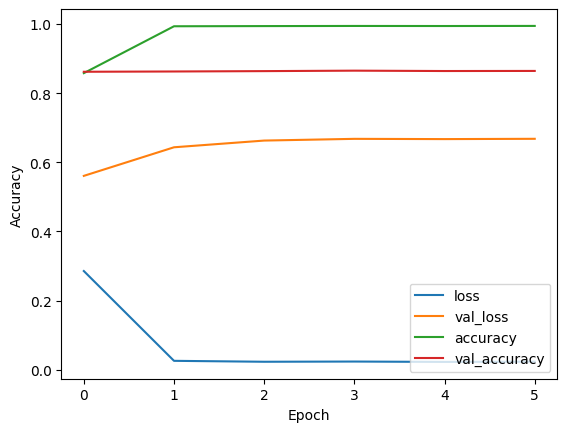

In [49]:
import matplotlib.pyplot as plt
# Funció auxiliar per graficar accuracy i loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.plot(history.history['binary_accuracy'], label='accuracy')
plt.plot(history.history['val_binary_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

In [50]:
from sklearn.metrics import roc_curve, accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay, classification_report
y_atent_pred = classifier_model.predict(test_ds)
y_atent = [1 if i[0] >= 0.5 else 0 for i in y_atent_pred ]
accuracy = accuracy_score(y_test, y_atent)
cm = confusion_matrix(y_test, y_atent)
sensitivity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
roc_auc = roc_auc_score(y_test,[ i[0] for i in y_atent_pred ])
 
print("Logistic Regression - Original Features")
print(f"Accuracy: {accuracy}")
print(f"Sensitivity: {sensitivity}")
print(f"Specificity: {specificity}")
print(f"ROC-AUC: {roc_auc}")
print("Confusion Matrix:")
print(cm)
print(classification_report(y_test, y_atent))

782/782 [==============================] - 59s 76ms/step
Logistic Regression - Original Features
Accuracy: 0.86152
Sensitivity: 0.87592
Specificity: 0.84712
ROC-AUC: 0.9363699232
Confusion Matrix:
[[10589  1911]
 [ 1551 10949]]
              precision    recall  f1-score   support

           0       0.87      0.85      0.86     12500
           1       0.85      0.88      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
    He congelat la capa de brert_basic entrenada i despres l'he posat un dropout per intentar evitar el sobreentrenament seguit d'una densa i un altre dorpout, veiem com la accuracy ha pujat una mica, clarament això ens pot servir per especificar un model generalista estalviant el temps de entrenar tota la bert que gasta molt temps
</div>

 Model | Accuracy |
|-------|----------|
| LSTM  | 0.8624     |
| ATT_simple  | 0.85056     |
| ATT_multiple | 0.86644   |
| Bert_basic | 0.85628   |
| Bert_biger | 0.89096   |
| Bert_freeze | 0.86152 |

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [1.5 pt]:</strong>  Catastrophic forgetting.

A la secció 5.3.3 del paper How to Fine-Tune BERT for Text Classification? https://arxiv.org/pdf/1905.05583v3 s'estudia el Catastrophic forgetting. Aquesta situació és molt delicada en els models de transformers de gran escala i s'ha de comprendre molt bé per evitar aquestes situacions

* Reprodueix la figura "Figure 2: Catastrophic Forgetting" d'aquest article científic. En concret, les subfigures c i d. Només cal que ho facis sobre la corba de train. L'eix x d'aquestes figures (iterations), pots considerar que són els batches d'entrenament, mentre que l'eix Y fa referència al loss. No cal que utilitzis exactament els valors de lr que es mostren en aquesta figura. L'objectiu és que mostris un cas en què el lr és tan gran que es produeix el Catastrophic forgetting, i un altre cas amb un altre valor en què això no passa.
</div>

In [63]:
classifier_model_lr_alta = build_classifier_model()

In [64]:
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
metrics = tf.metrics.BinaryAccuracy()
epochs = 3
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1*num_train_steps)
class BatchMetricsLogger(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.batch_losses = []
        self.batch_accuracies = []

    def on_train_batch_end(self, batch, logs=None):
        self.batch_losses.append(logs.get('loss'))
        self.batch_accuracies.append(logs.get('binary_accuracy'))

# Create the callback
batch_logger = BatchMetricsLogger()
init_lr = 5e-3
optimizer = optimization.create_optimizer(init_lr=init_lr,
                                          num_train_steps=num_train_steps,
                                          num_warmup_steps=num_warmup_steps,
                                          optimizer_type='adamw')
checkpoint_filepath = '/kaggle/temp/model_att2'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)
# Train
callback = EarlyStopping(monitor='val_loss', patience=3)

classifier_model_lr_alta.compile(optimizer=optimizer,
                         loss=loss,
                         metrics=metrics)
history = classifier_model_lr_alta.fit(train_ds,
                            validation_data=val_ds,
                               epochs=epochs,
                              callbacks=[callback, model_checkpoint_callback,batch_logger])

Epoch 1/3
665/665 [==============================] - 145s 206ms/step - loss: 0.7441 - binary_accuracy: 0.5226 - val_loss: 0.7108 - val_binary_accuracy: 0.5051
Epoch 2/3
665/665 [==============================] - 141s 212ms/step - loss: 0.7229 - binary_accuracy: 0.5016 - val_loss: 0.7410 - val_binary_accuracy: 0.5051
Epoch 3/3
665/665 [==============================] - 142s 214ms/step - loss: 0.7065 - binary_accuracy: 0.5053 - val_loss: 0.6932 - val_binary_accuracy: 0.5051


In [65]:
losses = batch_logger.batch_losses
accuracies = batch_logger.batch_accuracies

# Example: print first 5 batches
for i in range(5):
    print(f"Batch {i+1}: Loss = {losses[i]:.4f}, Accuracy = {accuracies[i]:.4f}")
losses = batch_logger.batch_losses
accuracies = batch_logger.batch_accuracies

# Example: print first 5 batches
for i in range(5):
    print(f"Batch {i+1}: Loss = {losses[i]:.4f}, Accuracy = {accuracies[i]:.4f}")



Batch 1: Loss = 0.6639, Accuracy = 0.6562
Batch 2: Loss = 0.6794, Accuracy = 0.6094
Batch 3: Loss = 0.7028, Accuracy = 0.5729
Batch 4: Loss = 0.7064, Accuracy = 0.5703
Batch 5: Loss = 0.6967, Accuracy = 0.5750
Batch 1: Loss = 0.6639, Accuracy = 0.6562
Batch 2: Loss = 0.6794, Accuracy = 0.6094
Batch 3: Loss = 0.7028, Accuracy = 0.5729
Batch 4: Loss = 0.7064, Accuracy = 0.5703
Batch 5: Loss = 0.6967, Accuracy = 0.5750


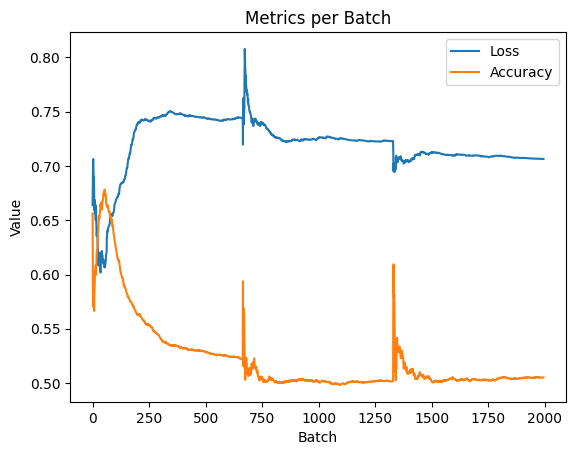

In [66]:
import matplotlib.pyplot as plt

plt.plot(losses, label='Loss')
plt.plot(accuracies, label='Accuracy')
plt.xlabel('Batch')
plt.ylabel('Value')
plt.legend()
plt.title('Metrics per Batch')
plt.show()

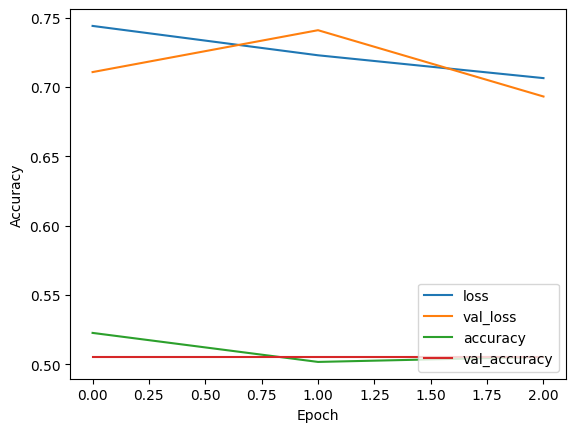

In [67]:
import matplotlib.pyplot as plt
# Funció auxiliar per graficar accuracy i loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.plot(history.history['binary_accuracy'], label='accuracy')
plt.plot(history.history['val_binary_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
    Veiem que quan accelerem el learnig rate l'entrenament no fucnion, en la grafica de accuracy per batch veiem com comencem amb una accuracy del 0.6 i va pujant cap al 0.7 pero veiem que rapidament oblida tot l'aprenut fins tenir una capacitat predictiva del 0.5 es a dir totalment aleatori
</div>

## 7 Estratègia final. (1 punt)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [1 pt]:</strong>
Amb tot allò que has après. Finalment, entrena un model de BERT per a classificació i intenta obtenir els millors resultats possibles.

In [37]:
tfhub_handle_preprocess = 'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3'
tfhub_handle_encoder = 'https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3'
def build_classifier_best():
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)
    net = outputs['pooled_output']
    net = tf.keras.layers.Dropout(0.3)(net)

    net = tf.keras.layers.Dense(128, activation='relu')(net)
    net = tf.keras.layers.Dropout(0.1)(net)
    net = tf.keras.layers.Dense(1, activation='sigmoid', name='classifier')(net)
    return tf.keras.Model(text_input, net)
classifier_model_best = build_classifier_best()
classifier_model_best.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_mask': (None, 128)   0         ['text[0][0]']                
                             , 'input_type_ids': (None,                                           
                              128),                                                               
                              'input_word_ids': (None,                                            
                             128)}                                                                
                                                                                            

In [35]:
x_train, x_val = x_train_full[:21250], x_train_full[21250:]
y_train, y_val = y_train_full[:21250], y_train_full[21250:]
x_train_bert = [decode(review) for review in x_train]
x_val_bert = [decode(review) for review in x_val]
x_test_bert = [decode(review) for review in x_test]
train_ds = tf.data.Dataset.from_tensor_slices((x_train_bert, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((x_val_bert, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((x_test_bert, y_test))


BATCH_SIZE = 32

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
import numpy as np

epochs = 5

checkpoint_filepath = '/kaggle/temp/model_best'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)
# Train
callback = EarlyStopping(monitor='val_loss', patience=2)

classifier_model_best.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history = classifier_model_best.fit(train_ds, validation_data=val_ds,
                               epochs=epochs, batch_size=64,
                              callbacks=[callback, model_checkpoint_callback])


In [ ]:
import matplotlib.pyplot as plt
# Funció auxiliar per graficar accuracy i loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

In [ ]:
from sklearn.metrics import roc_curve, accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay, classification_report
y_atent_pred = classifier_model_best.predict(test_ds)
y_atent = [1 if i[0] >= 0.5 else 0 for i in y_atent_pred ]
accuracy = accuracy_score(y_test, y_atent)
cm = confusion_matrix(y_test, y_atent)
sensitivity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
roc_auc = roc_auc_score(y_test,[ i[0] for i in y_atent_pred ])
 
print("Logistic Regression - Original Features")
print(f"Accuracy: {accuracy}")
print(f"Sensitivity: {sensitivity}")
print(f"Specificity: {specificity}")
print(f"ROC-AUC: {roc_auc}")
print("Confusion Matrix:")
print(cm)
print(classification_report(y_test, y_atent))

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
    He probat diferents models, el millor que tinc es la resolusio actual, he arribat a 0.9 no he pugut res millor encara que els papers deien que 0.95 es posible, ho he fet a kaggle i m'he quedat sese credits de GPU per tant no ho puc intentar millorar no tinc outputs per la mateixa rao, el que he intentat es utilizar una bert gran i despres unes capes profundes amb drop per evitar el sobre ajust, he llegit teoria i deien que amb el bert nomes podries arribar a aquest punts pero no he pugut reproduir-ho
</div>